# Store Customer Data Profiling, Cleansing and Descriptive Analytics

This section uses only the data already loaded into the `datawarehouse` schema.

### Additional operations implemented
1. **Data profiling** – audit the warehouse fact data for duplicates, invalid business values and orphaned dimension links.
2. **Data cleansing** – build a cleaned analytical DataFrame for store-customer analysis while preserving the raw warehouse tables unchanged.
3. **Descriptive analytics for store customers** – visualise top store customers, monthly sales trends, and the relationship between discounting and shipping lead time.

In [1]:
import mysql.connector
import pandas as pd
from matplotlib import pyplot as plt

import bt4301

bt4301.set_default_pandas_options(max_columns=50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
db_datawarehouse = mysql.connector.connect(
    host='localhost',
    user='bt4301',
    passwd='password',
    database='datawarehouse'
)


In [4]:
str_sql = '''
SELECT
    f.fact_store_sales_key,
    f.sales_order_id,
    f.sales_order_detail_id,
    f.sales_order_number,
    c.customer_id,
    c.store_id,
    c.store_name,
    c.territory_id,
    p.product_id,
    p.product_name,
    p.product_subcategory_name,
    p.product_category_name,
    t.full_date AS order_date,
    t.year_num,
    t.month_num,
    t.month_name,
    CONCAT(t.year_num, '-', LPAD(t.month_num, 2, '0')) AS `year_month`,
    s.salesperson_id,
    s.full_name AS salesperson_name,
    f.order_qty,
    f.unit_price,
    f.unit_price_discount,
    f.gross_amount,
    f.discount_amount,
    f.margin_amount,
    f.net_amount,
    f.header_subtotal,
    f.header_tax_amt,
    f.header_freight,
    f.header_total_due
FROM fact_store_sales f
LEFT JOIN dim_store_customer c
    ON f.customer_key = c.customer_key
LEFT JOIN dim_product p
    ON f.product_key = p.product_key
LEFT JOIN dim_time t
    ON f.order_date_key = t.time_key
LEFT JOIN dim_salesperson s
    ON f.salesperson_key = s.salesperson_key
ORDER BY t.full_date, f.sales_order_id, f.sales_order_detail_id ASC;
'''
df_store = pd.read_sql(sql=str_sql, con=db_datawarehouse)

print('Rows loaded:', len(df_store))
df_store.head()

/tmp/ipykernel_581/1137690667.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_store = pd.read_sql(sql=str_sql, con=db_datawarehouse)


Rows loaded: 60919


,fact_store_sales_key,sales_order_id,sales_order_detail_id,sales_order_number,customer_id,store_id,store_name,territory_id,product_id,product_name,product_subcategory_name,product_category_name,order_date,year_num,month_num,month_name,year_month,salesperson_id,salesperson_name,order_qty,unit_price,unit_price_discount,gross_amount,discount_amount,margin_amount,net_amount,header_subtotal,header_tax_amt,header_freight,header_total_due
0,1,43659,1,SO43659,29825,1046,Better Bike Shop,5,776,"Mountain-100 Black, 42",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2024.99,0.00,2024.99,0.00,126.90,2024.99,20565.62,1971.51,616.10,23153.23
1,2,43659,2,SO43659,29825,1046,Better Bike Shop,5,777,"Mountain-100 Black, 44",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,3,2024.99,0.00,6074.98,0.00,380.70,6074.98,20565.62,1971.51,616.10,23153.23
2,3,43659,3,SO43659,29825,1046,Better Bike Shop,5,778,"Mountain-100 Black, 48",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2024.99,0.00,2024.99,0.00,126.90,2024.99,20565.62,1971.51,616.10,23153.23
3,4,43659,4,SO43659,29825,1046,Better Bike Shop,5,771,"Mountain-100 Silver, 38",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2039.99,0.00,2039.99,0.00,127.84,2039.99,20565.62,1971.51,616.10,23153.23
4,5,43659,5,SO43659,29825,1046,Better Bike Shop,5,772,"Mountain-100 Silver, 42",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2039.99,0.00,2039.99,0.00,127.84,2039.99,20565.62,1971.51,616.10,23153.23


## Operation 1 – Data profiling and warehouse quality audit

This operation checks the store-customer sales mart for:
- duplicate fact rows at order-line grain
- orphaned dimension links
- invalid discounts
- non-positive quantity or price
- negative shipping lead time

This is useful because even if the ETL loaded successfully, warehouse data can still contain business-rule violations or modelling issues that should be identified before analysis.

In [18]:
quality_summary = pd.DataFrame({
    'Check': [
        'Duplicate fact rows by (sales_order_id, sales_order_detail_id)',
        'Missing store dimension attributes',
        'Missing product dimension attributes',
        'Missing time dimension attributes',
        'Missing salesperson dimension attributes',
        'Invalid discount rate (< 0 or > 1)',
        'Non-positive order quantity',
        'Negative unit price',
    ],
    'IssueCount': [
        df_store.duplicated(subset=['sales_order_id', 'sales_order_detail_id']).sum(),
        df_store['store_name'].isna().sum(),
        df_store['product_name'].isna().sum(),
        df_store['order_date'].isna().sum(),
        df_store['salesperson_name'].isna().sum(),
        (~df_store['unit_price_discount'].between(0, 1, inclusive='both')).sum(),
        (df_store['order_qty'] <= 0).sum(),
        (df_store['unit_price'] < 0).sum(),
    ]
})

quality_summary

,Check,IssueCount
0,"Duplicate fact rows by (sales_order_id, sales_...",0
1,Missing store dimension attributes,0
2,Missing product dimension attributes,0
3,Missing time dimension attributes,0
4,Missing salesperson dimension attributes,0
5,Invalid discount rate (< 0 or > 1),0
6,Non-positive order quantity,0
7,Negative unit price,0


## Operation 2 – Data cleansing for analytical use

The warehouse raw and fact tables are not modified.

Instead, a cleaned analytical DataFrame is created by:
- removing duplicate order-line rows
- keeping only rows with positive quantity
- keeping only rows with non-negative price
- keeping only rows with discount rates between 0 and 1
- keeping only rows with non-negative shipping lead days or null shipping lead days

This preserves the raw warehouse data while ensuring the downstream analysis uses valid store-customer transaction records.

In [8]:
df_store_clean = df_store.copy()

df_store_clean = df_store_clean.drop_duplicates(
    subset=['sales_order_id', 'sales_order_detail_id']
)

df_store_clean = df_store_clean[
    (df_store_clean['order_qty'] > 0) &
    (df_store_clean['unit_price'] >= 0) &
    (df_store_clean['unit_price_discount'].between(0, 1, inclusive='both')) &
    (df_store_clean['net_amount'] >= 0)
].copy()

df_store_clean['margin_amount'] = pd.to_numeric(df_store_clean['margin_amount'], errors='coerce')
df_store_clean['gross_amount'] = pd.to_numeric(df_store_clean['gross_amount'], errors='coerce')
df_store_clean['discount_amount'] = pd.to_numeric(df_store_clean['discount_amount'], errors='coerce')
df_store_clean['net_amount'] = pd.to_numeric(df_store_clean['net_amount'], errors='coerce')

print('Rows after cleaning:', len(df_store_clean))
df_store_clean.head()

Rows after cleaning: 60919


,fact_store_sales_key,sales_order_id,sales_order_detail_id,sales_order_number,customer_id,store_id,store_name,territory_id,product_id,product_name,product_subcategory_name,product_category_name,order_date,year_num,month_num,month_name,year_month,salesperson_id,salesperson_name,order_qty,unit_price,unit_price_discount,gross_amount,discount_amount,margin_amount,net_amount,header_subtotal,header_tax_amt,header_freight,header_total_due
0,1,43659,1,SO43659,29825,1046,Better Bike Shop,5,776,"Mountain-100 Black, 42",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2024.99,0.00,2024.99,0.00,126.90,2024.99,20565.62,1971.51,616.10,23153.23
1,2,43659,2,SO43659,29825,1046,Better Bike Shop,5,777,"Mountain-100 Black, 44",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,3,2024.99,0.00,6074.98,0.00,380.70,6074.98,20565.62,1971.51,616.10,23153.23
2,3,43659,3,SO43659,29825,1046,Better Bike Shop,5,778,"Mountain-100 Black, 48",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2024.99,0.00,2024.99,0.00,126.90,2024.99,20565.62,1971.51,616.10,23153.23
3,4,43659,4,SO43659,29825,1046,Better Bike Shop,5,771,"Mountain-100 Silver, 38",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2039.99,0.00,2039.99,0.00,127.84,2039.99,20565.62,1971.51,616.10,23153.23
4,5,43659,5,SO43659,29825,1046,Better Bike Shop,5,772,"Mountain-100 Silver, 42",Mountain Bikes,Bikes,2005-07-01,2005,7,July,2005-07,279,Tsvi Michael Reiter,1,2039.99,0.00,2039.99,0.00,127.84,2039.99,20565.62,1971.51,616.10,23153.23


In [9]:
bt4301.data_quality_report(df_store_clean)

,fact_store_sales_key,sales_order_id,sales_order_detail_id,sales_order_number,customer_id,store_id,store_name,territory_id,product_id,product_name,product_subcategory_name,product_category_name,order_date,year_num,month_num,month_name,year_month,salesperson_id,salesperson_name,order_qty,unit_price,unit_price_discount,gross_amount,discount_amount,margin_amount,net_amount,header_subtotal,header_tax_amt,header_freight,header_total_due
count,60919.00,60919.00,60919.00,60919,60919.00,60919.00,60919,60919.00,60919.00,60919,60919,60919,60919,60919.00,60919.00,60919,60919,60919.00,60919,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00,60919.00
unique,NaN,NaN,NaN,3806,NaN,NaN,633,NaN,NaN,250,33,4,40,NaN,NaN,12,36,NaN,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,SO51721,NaN,NaN,Vigorous Exercise Company,NaN,NaN,AWC Logo Cap,Road Bikes,Bikes,2007-09-01,NaN,NaN,August,2007-09,NaN,Jillian Carson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,72,NaN,NaN,530,NaN,NaN,1192,12876,24826,3768,NaN,NaN,7515,3768,NaN,7825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,30460.00,53839.75,44731.44,NaN,29802.50,1047.57,NaN,4.59,831.39,NaN,NaN,NaN,NaN,2006.81,7.00,NaN,NaN,280.77,NaN,3.52,444.28,0.01,1329.88,8.66,-38.02,1321.22,41649.46,4055.73,1267.42,46972.60
std,17585.94,8109.17,32663.25,NaN,186.46,486.73,NaN,2.44,86.62,NaN,NaN,NaN,NaN,0.85,3.27,NaN,NaN,5.02,NaN,3.03,519.85,0.03,2140.47,87.70,405.32,2123.41,28178.89,2771.74,866.17,31806.74
min,1.00,43659.00,1.00,NaN,29484.00,292.00,NaN,1.00,707.00,NaN,NaN,NaN,NaN,2005.00,1.00,NaN,NaN,274.00,NaN,1.00,1.33,0.00,1.37,0.00,-15099.75,1.37,1.37,0.11,0.03,1.52
25%,15230.50,47455.00,17970.50,NaN,29641.00,652.00,NaN,3.00,762.00,NaN,NaN,NaN,NaN,2006.00,5.00,NaN,NaN,277.00,NaN,2.00,34.92,0.00,127.80,0.00,-52.48,127.80,23686.98,2298.18,718.18,26747.30
50%,30460.00,51092.00,35888.00,NaN,29795.00,982.00,NaN,4.00,815.00,NaN,NaN,NaN,NaN,2007.00,7.00,NaN,NaN,279.00,NaN,3.00,209.26,0.00,461.69,0.00,1.81,461.69,37020.04,3572.41,1116.38,41690.13
75%,45689.50,58951.00,68552.50,NaN,29956.00,1334.00,NaN,6.00,893.00,NaN,NaN,NaN,NaN,2007.00,10.00,NaN,NaN,284.00,NaN,4.00,672.29,0.00,1472.29,0.00,41.51,1466.01,56353.87,5481.55,1712.99,63500.48


## Operation 3 – Descriptive analytics for store customers

The following store-customer visualisations are produced:

1. **Top store customers by net sales, with profit quality shown as margin %**
2. **Discount dependence vs profitability by store customer**
3. **Product category performance for store customers**
4. **Salesperson performance for store customers**


In [10]:
df_store_perf = (
    df_store_clean.groupby('store_name', as_index=False)
    .agg(
        net_sales=('net_amount', 'sum'),
        gross_sales=('gross_amount', 'sum'),
        discount_value=('discount_amount', 'sum'),
        margin_value=('margin_amount', 'sum'),
        order_lines=('sales_order_detail_id', 'count')
    )
)

df_store_perf = df_store_perf[df_store_perf['net_sales'] > 0].copy()
df_store_perf['margin_pct'] = (df_store_perf['margin_value'] / df_store_perf['net_sales']) * 100

df_top_store_perf = df_store_perf.sort_values('net_sales', ascending=False).head(10).copy()
df_top_store_perf

,store_name,net_sales,gross_sales,discount_value,margin_value,order_lines,margin_pct
57,Brakes and Gears,877107.19,882276.50,5169.30,38042.24,298,4.34
139,Excellent Riding Supplies,853849.18,853850.64,1.46,-63507.64,366,-7.44
604,Vigorous Exercise Company,841908.77,860147.51,18238.74,-29577.75,530,-3.51
562,Totes & Baskets Company,816755.58,817127.80,372.23,-60114.74,436,-7.36
445,Retail Mall,799277.90,803769.85,4491.96,-65776.97,451,-8.23
94,Corner Bicycle Supply,787773.04,787808.83,35.79,-55915.38,429,-7.10
370,Outdoor Equipment Store,746317.53,751632.86,5315.33,-67828.49,332,-9.09
553,Thorough Parts and Repair Services,740985.83,741363.22,377.38,-49161.78,358,-6.63
250,"Health Spa, Limited",730798.71,735235.70,4436.99,-59331.01,352,-8.12
197,Fitness Toy Store,727272.65,731636.86,4364.21,-63705.35,336,-8.76


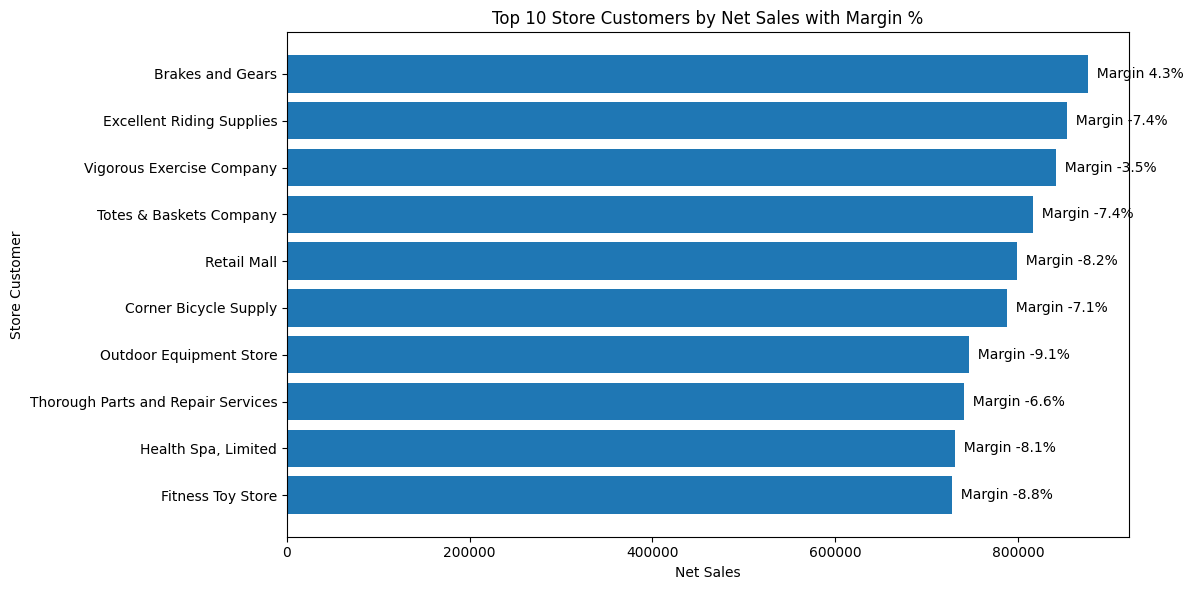

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_df = df_top_store_perf.sort_values('net_sales')
ax.barh(plot_df['store_name'], plot_df['net_sales'])

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row['net_sales'],
        i,
        f"  Margin {row['margin_pct']:.1f}%",
        va='center'
    )

ax.set_title('Top 10 Store Customers by Net Sales with Margin %')
ax.set_xlabel('Net Sales')
ax.set_ylabel('Store Customer')
plt.tight_layout()
plt.show()

In [12]:
df_discount_profit = (
    df_store_clean.groupby('store_name', as_index=False)
    .agg(
        gross_sales=('gross_amount', 'sum'),
        discount_value=('discount_amount', 'sum'),
        net_sales=('net_amount', 'sum'),
        margin_value=('margin_amount', 'sum'),
        order_lines=('sales_order_detail_id', 'count')
    )
)

df_discount_profit = df_discount_profit[
    (df_discount_profit['gross_sales'] > 0) &
    (df_discount_profit['net_sales'] > 0)
].copy()

df_discount_profit['discount_ratio_pct'] = (
    df_discount_profit['discount_value'] / df_discount_profit['gross_sales']
) * 100

df_discount_profit['margin_pct'] = (
    df_discount_profit['margin_value'] / df_discount_profit['net_sales']
) * 100

# Keep only materially relevant stores for readability
df_discount_profit = df_discount_profit.sort_values('net_sales', ascending=False).head(20)
df_discount_profit

,store_name,gross_sales,discount_value,net_sales,margin_value,order_lines,discount_ratio_pct,margin_pct
57,Brakes and Gears,882276.50,5169.30,877107.19,38042.24,298,0.59,4.34
139,Excellent Riding Supplies,853850.64,1.46,853849.18,-63507.64,366,0.00,-7.44
604,Vigorous Exercise Company,860147.51,18238.74,841908.77,-29577.75,530,2.12,-3.51
562,Totes & Baskets Company,817127.80,372.23,816755.58,-60114.74,436,0.05,-7.36
445,Retail Mall,803769.85,4491.96,799277.90,-65776.97,451,0.56,-8.23
94,Corner Bicycle Supply,787808.83,35.79,787773.04,-55915.38,429,0.00,-7.10
370,Outdoor Equipment Store,751632.86,5315.33,746317.53,-67828.49,332,0.71,-9.09
553,Thorough Parts and Repair Services,741363.22,377.38,740985.83,-49161.78,358,0.05,-6.63
250,"Health Spa, Limited",735235.70,4436.99,730798.71,-59331.01,352,0.60,-8.12
197,Fitness Toy Store,731636.86,4364.21,727272.65,-63705.35,336,0.60,-8.76


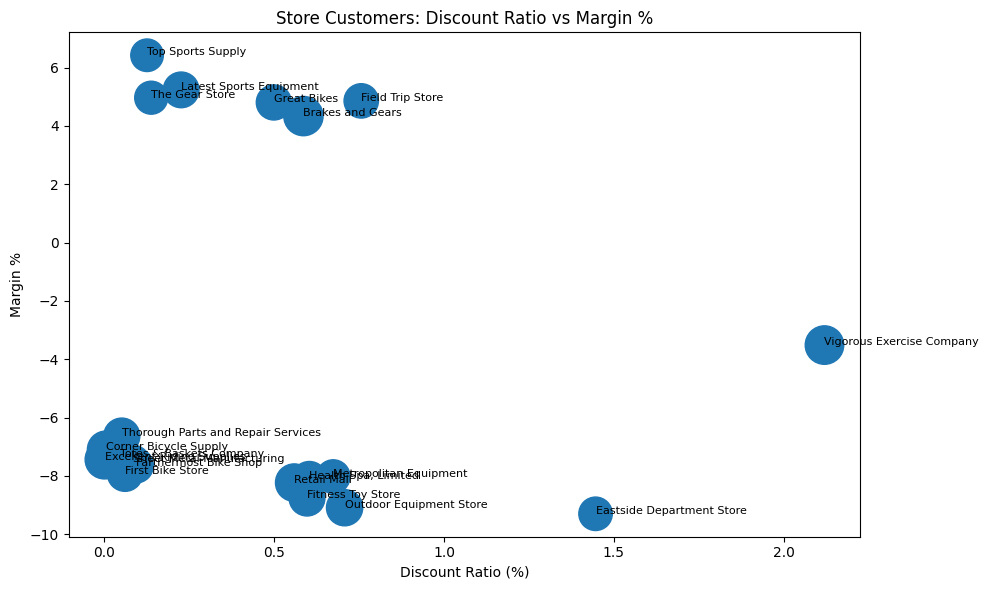

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_discount_profit['discount_ratio_pct'],
    df_discount_profit['margin_pct'],
    s=df_discount_profit['net_sales'] / df_discount_profit['net_sales'].max() * 800
)

for _, row in df_discount_profit.iterrows():
    ax.annotate(
        row['store_name'],
        (row['discount_ratio_pct'], row['margin_pct']),
        fontsize=8
    )

ax.set_title('Store Customers: Discount Ratio vs Margin %')
ax.set_xlabel('Discount Ratio (%)')
ax.set_ylabel('Margin %')
plt.tight_layout()
plt.show()

In [14]:
df_category_perf = (
    df_store_clean.groupby('product_category_name', as_index=False)
    .agg(
        net_sales=('net_amount', 'sum'),
        margin_value=('margin_amount', 'sum'),
        discount_value=('discount_amount', 'sum'),
        order_lines=('sales_order_detail_id', 'count')
    )
)

df_category_perf = df_category_perf[df_category_perf['net_sales'] > 0].copy()
df_category_perf['margin_pct'] = (df_category_perf['margin_value'] / df_category_perf['net_sales']) * 100

df_category_perf = df_category_perf.sort_values('net_sales', ascending=False).head(10)
df_category_perf

,product_category_name,net_sales,margin_value,discount_value,order_lines,margin_pct
1,Bikes,66333028.05,-3176461.71,494640.64,24826,-4.79
3,Components,11802593.29,490233.18,5214.74,18698,4.15
2,Clothing,1780769.91,172469.59,20964.50,12293,9.69
0,Accessories,571312.92,197719.69,6688.03,5102,34.61


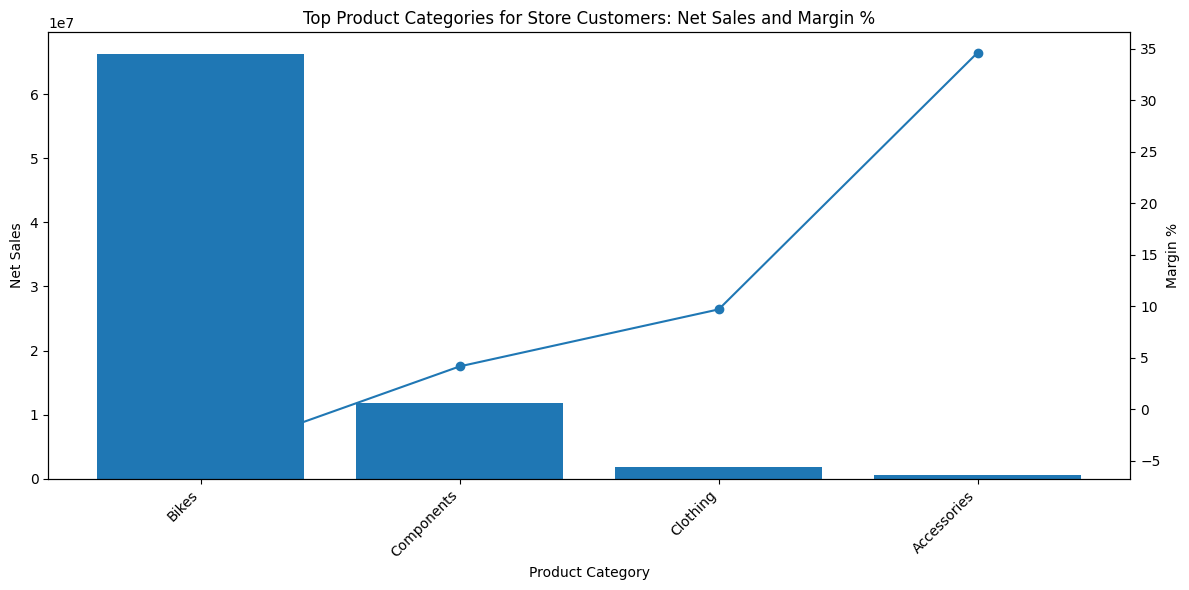

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_category_perf['product_category_name'], df_category_perf['net_sales'])
ax1.set_title('Top Product Categories for Store Customers: Net Sales and Margin %')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Net Sales')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_category_perf['product_category_name'], df_category_perf['margin_pct'], marker='o')
ax2.set_ylabel('Margin %')

plt.tight_layout()
plt.show()

In [16]:
df_salesperson_perf = (
    df_store_clean.groupby('salesperson_name', as_index=False)
    .agg(
        net_sales=('net_amount', 'sum'),
        margin_value=('margin_amount', 'sum'),
        discount_value=('discount_amount', 'sum'),
        order_lines=('sales_order_detail_id', 'count')
    )
)

df_salesperson_perf = df_salesperson_perf[
    df_salesperson_perf['salesperson_name'].notna()
].copy()

df_salesperson_perf = df_salesperson_perf[df_salesperson_perf['net_sales'] > 0].copy()
df_salesperson_perf['margin_pct'] = (
    df_salesperson_perf['margin_value'] / df_salesperson_perf['net_sales']
) * 100

df_salesperson_perf = df_salesperson_perf.sort_values('margin_value', ascending=False).head(10)
df_salesperson_perf

,salesperson_name,net_sales,margin_value,discount_value,order_lines,margin_pct
9,Pamela O Ansman-Wolfe,3325102.59,35603.66,14611.03,2064,1.07
14,Syed E Abbas,172524.45,-20766.44,5782.57,245,-12.04
0,Amy E Alberts,732759.18,-24279.29,5493.39,586,-3.31
1,David R Campbell,3729945.35,-40680.69,26916.27,2247,-1.09
7,Lynn N Tsoflias,1421810.92,-87954.44,22751.48,1468,-6.19
10,Rachel B Valdez,1827066.71,-89576.17,27263.92,1783,-4.90
13,Stephen Y Jiang,1092123.86,-91763.98,19638.15,792,-8.40
15,Tete A Mensa-Annan,2312545.69,-121358.79,15392.72,1893,-5.25
3,Jae B Pak,8503338.65,-142034.44,38475.67,6738,-1.67
2,Garrett R Vargas,3609447.21,-144573.06,22302.63,3284,-4.01


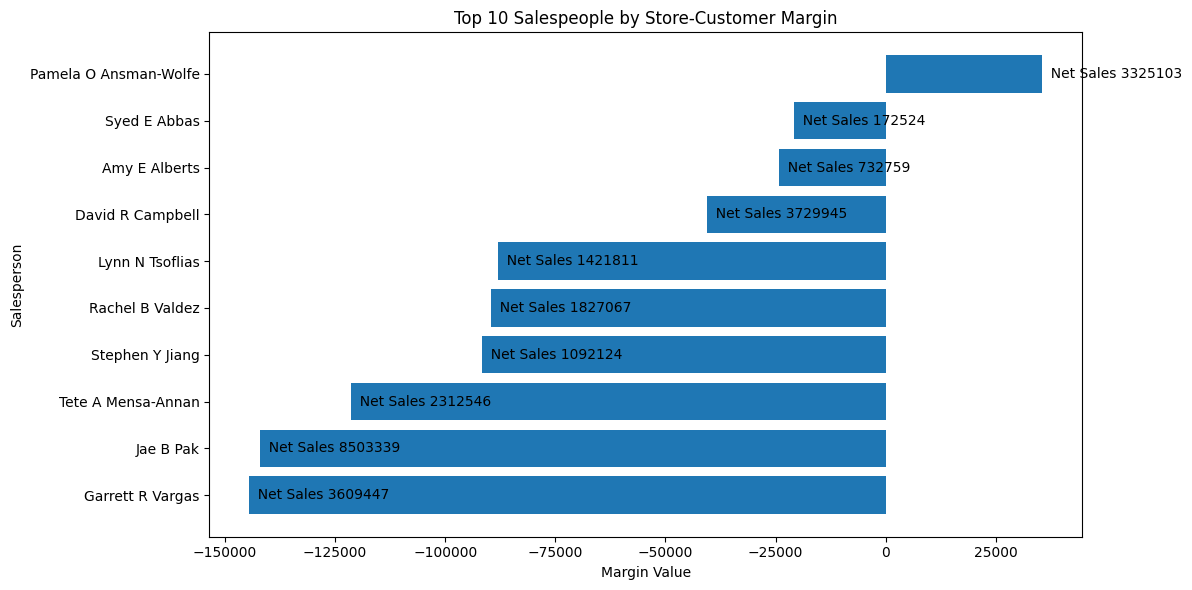

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_df = df_salesperson_perf.sort_values('margin_value')
ax.barh(plot_df['salesperson_name'], plot_df['margin_value'])

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row['margin_value'],
        i,
        f"  Net Sales {row['net_sales']:.0f}",
        va='center'
    )

ax.set_title('Top 10 Salespeople by Store-Customer Margin')
ax.set_xlabel('Margin Value')
ax.set_ylabel('Salesperson')
plt.tight_layout()
plt.show()

### Interpretation

- The quality audit confirms whether the warehouse fact table is suitable for downstream store-customer analysis.
- The cleaning step creates a valid analytical dataset without overwriting or discarding the raw warehouse data.
- The top-store sales chart identifies the most valuable B2B customers.
- The monthly trend chart shows whether store customers purchase steadily or in spikes.
- The discount vs shipping lead chart helps assess whether high-value store customers rely on stronger discounting and whether service levels differ across stores.